# Synthetic Relational Database Testbed for Rank Collapse & RAMA Validation

This notebook demonstrates a synthetic relational database testbed that generates parent-child
hierarchical data across **12 conditions** (4 cardinality regimes x 3 projection ranks).

**Key features:**
- Ground-truth SVD-based effective rank and cheap variance-entropy proxy
- Regression targets with nonlinear variance dependence
- Classification targets requiring variance information
- 7 validation checks verifying data quality

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed for this notebook

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # scipy 1.16.3 requires Python >=3.11; fall back to 1.15.3 on older Python
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time

import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/dataset_iter1_synthetic_relat/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded dataset with {len(data['datasets'][0]['examples'])} examples")
print(f"Metadata keys: {list(data['metadata'].keys())}")

Loaded dataset with 60 examples
Metadata keys: ['master_seed', 'noise_std', 'parent_dim', 'child_dim', 'conditions']


## Configuration

All tunable parameters for data generation. Start with minimum values for fast execution.

In [5]:
# ── Tunable parameters ──
# Using original values (generation is fast, pure numpy)

MASTER_SEED = 42
PARENT_DIM = 8
CHILD_DIM = 16
NOISE_STD = 0.1
DATASET_NAME = "synthetic_relational_rank_collapse_testbed"

# Cardinality regimes: (name, num_children, num_parents)
CARDINALITY_REGIMES = [
    ("low", 5, 500),
    ("medium", 50, 500),
    ("high", 500, 200),
    ("extreme", 2000, 50),
]

PROJECTION_RANKS = [2, 8, 16]

CONDITIONS = []
for ci, (card_name, n_children, n_parents) in enumerate(CARDINALITY_REGIMES):
    for ri, rank in enumerate(PROJECTION_RANKS):
        idx = ci * len(PROJECTION_RANKS) + ri
        CONDITIONS.append({
            "condition_name": f"{card_name}_rank{rank}",
            "cardinality_regime": card_name,
            "num_children": n_children,
            "num_parents": n_parents,
            "projection_rank": rank,
            "condition_index": idx,
        })

print(f"Configured {len(CONDITIONS)} conditions")
for c in CONDITIONS:
    print(f"  {c['condition_name']}: {c['num_children']} children x {c['num_parents']} parents")

Configured 12 conditions
  low_rank2: 5 children x 500 parents
  low_rank8: 5 children x 500 parents
  low_rank16: 5 children x 500 parents
  medium_rank2: 50 children x 500 parents
  medium_rank8: 50 children x 500 parents
  medium_rank16: 50 children x 500 parents
  high_rank2: 500 children x 200 parents
  high_rank8: 500 children x 200 parents
  high_rank16: 500 children x 200 parents
  extreme_rank2: 2000 children x 50 parents
  extreme_rank8: 2000 children x 50 parents
  extreme_rank16: 2000 children x 50 parents


## Explore Pre-generated Data

Examine the structure of examples from the loaded dataset.

In [6]:
examples = data["datasets"][0]["examples"]

# Show first example structure
ex = examples[0]
print("Example keys:", list(ex.keys()))
print(f"\nCondition: {ex['metadata_condition']}")
print(f"Fold: {ex['metadata_fold']}")
print(f"Cardinality: {ex['metadata_cardinality']}")
print(f"Projection rank: {ex['metadata_projection_rank']}")
print(f"Effective rank (SVD): {ex['metadata_erank_svd']:.4f}")
print(f"Effective rank (proxy): {ex['metadata_erank_proxy']:.4f}")

# Parse input/output
inp = json.loads(ex["input"])
out = json.loads(ex["output"])
print(f"\nInput: {len(inp['parent_features'])} parent features, "
      f"{inp['num_children']} children x {len(inp['child_features'][0])} dims")
print(f"Output: regression_target={out['regression_target']:.4f}, "
      f"classification_target={out['classification_target']}")

# Count examples per condition
from collections import Counter
cond_counts = Counter(e["metadata_condition"] for e in examples)
print(f"\nExamples per condition:")
for cond, count in sorted(cond_counts.items()):
    print(f"  {cond}: {count}")

Example keys: ['input', 'output', 'metadata_fold', 'metadata_condition', 'metadata_cardinality_regime', 'metadata_cardinality', 'metadata_projection_rank', 'metadata_parent_id', 'metadata_erank_svd', 'metadata_erank_proxy', 'metadata_child_mean', 'metadata_child_variance']

Condition: low_rank2
Fold: train
Cardinality: 5
Projection rank: 2
Effective rank (SVD): 2.1276
Effective rank (proxy): 0.6822

Input: 8 parent features, 5 children x 16 dims
Output: regression_target=10.7227, classification_target=1

Examples per condition:
  extreme_rank16: 5
  extreme_rank2: 5
  extreme_rank8: 5
  high_rank16: 5
  high_rank2: 5
  high_rank8: 5
  low_rank16: 5
  low_rank2: 5
  low_rank8: 5
  medium_rank16: 5
  medium_rank2: 5
  medium_rank8: 5


## Helper Functions

Utility functions for rounding arrays (matching the original script).

In [7]:
def round_list(arr, decimals=4):
    """Round a 1D numpy array to a list of floats."""
    return [round(float(x), decimals) for x in arr]


def round_nested_list(arr, decimals=4):
    """Round a 2D numpy array to a nested list of floats."""
    return [[round(float(x), decimals) for x in row] for row in arr]

## Per-Condition Data Generation

Generate parent-child relational data for a single condition. Each parent has
a set of child feature vectors spanning a controllable subspace, plus SVD-based
effective rank, variance-entropy proxy, and regression/classification targets.

In [8]:
def generate_condition(cond):
    """Generate all parent-child data for one condition."""
    idx = cond["condition_index"]
    rank = cond["projection_rank"]
    n_children = cond["num_children"]
    n_parents = cond["num_parents"]
    card_name = cond["cardinality_regime"]
    cond_name = cond["condition_name"]

    rng = np.random.default_rng(MASTER_SEED + idx)

    # Parent features — shape (num_parents, 8)
    parent_features = rng.standard_normal((n_parents, PARENT_DIM))

    # Projection matrix A — orthonormal columns, shape (16, rank)
    raw = rng.standard_normal((CHILD_DIM, rank))
    A, _ = np.linalg.qr(raw)

    # Parent-to-child bias matrix B — shape (16, 8)
    B = rng.standard_normal((CHILD_DIM, PARENT_DIM)) * 0.5

    # Weight vectors for targets
    w_mean = rng.standard_normal(CHILD_DIM)
    w_var = np.abs(rng.standard_normal(CHILD_DIM)) * 4.0  # all-positive, amplified
    w_cross = rng.standard_normal(CHILD_DIM) * 1.5

    # Parent-dependent variance scaling
    var_scale_weights = rng.standard_normal(PARENT_DIM) * 0.5

    parent_data = []
    for p in range(n_parents):
        scale_p = float(np.exp(np.dot(var_scale_weights, parent_features[p])))
        scale_p = np.clip(scale_p, 0.3, 3.0)

        z = rng.standard_normal((n_children, rank))
        structured = (scale_p * z) @ A.T
        bias = B @ parent_features[p]
        noise = rng.standard_normal((n_children, CHILD_DIM)) * NOISE_STD
        child_feats = structured + bias + noise

        mu = child_feats.mean(axis=0)
        var_per_dim = child_feats.var(axis=0)

        # SVD-based effective rank
        centered = child_feats - mu
        cov = (centered.T @ centered) / n_children
        sigmas = np.linalg.svd(cov, compute_uv=False)
        sigmas_pos = np.maximum(sigmas, 1e-12)
        p_svd = sigmas_pos / sigmas_pos.sum()
        H_svd = -np.sum(p_svd * np.log(p_svd))
        erank_svd = float(np.exp(H_svd))

        # Cheap variance-entropy proxy
        var_pos = np.maximum(var_per_dim, 1e-12)
        p_var = var_pos / var_pos.sum()
        H_var = -np.sum(p_var * np.log(p_var))
        erank_proxy = float(np.exp(H_var)) / CHILD_DIM

        # Regression target
        y_mean_comp = float(np.sum(w_mean * np.sin(mu)))
        y_var_comp = float(np.sum(w_var * np.sqrt(var_per_dim + 0.01)))
        y_cross_comp = float(np.sum(w_cross * mu * var_per_dim))
        y_direct_var = 0.5 * float(np.sum(var_per_dim))
        y = y_mean_comp + y_var_comp + y_cross_comp + y_direct_var + float(rng.normal(0, 0.1))

        total_var = float(np.sum(var_per_dim))

        parent_data.append({
            "parent_features": parent_features[p],
            "child_feats": child_feats,
            "mu": mu,
            "var_per_dim": var_per_dim,
            "erank_svd": erank_svd,
            "erank_proxy": erank_proxy,
            "regression_target": y,
            "total_var": total_var,
            "parent_id": p,
        })

    # Classification target — median split with fuzzy boundary
    total_vars = np.array([pd["total_var"] for pd in parent_data])
    median_var = float(np.median(total_vars))
    distances_to_median = np.abs(total_vars - median_var)
    dist_20th_pct = float(np.percentile(distances_to_median, 20))

    for pd in parent_data:
        tv = pd["total_var"]
        base_label = 1 if tv > median_var else 0
        dist = abs(tv - median_var)
        if dist <= dist_20th_pct and dist_20th_pct > 0:
            mu_sum = float(np.sum(pd["mu"][:4]))
            logit = -2.0 * dist / max(dist_20th_pct, 1e-8) + 0.3 * mu_sum
            flip_prob = 1.0 / (1.0 + np.exp(-logit))
            if rng.random() < flip_prob * 0.3:
                base_label = 1 - base_label
        pd["classification_target"] = base_label

    # Train/val/test split (60/20/20)
    indices = np.arange(n_parents)
    rng.shuffle(indices)
    n_train = int(0.6 * n_parents)
    n_val = int(0.2 * n_parents)
    folds = {}
    for i, idx_val in enumerate(indices):
        if i < n_train:
            folds[int(idx_val)] = "train"
        elif i < n_train + n_val:
            folds[int(idx_val)] = "val"
        else:
            folds[int(idx_val)] = "test"

    # Assemble schema-compliant rows
    rows = []
    for pd in parent_data:
        pid = pd["parent_id"]
        input_obj = {
            "parent_features": round_list(pd["parent_features"]),
            "child_features": round_nested_list(pd["child_feats"]),
            "num_children": n_children,
        }
        output_obj = {
            "regression_target": round(pd["regression_target"], 4),
            "classification_target": pd["classification_target"],
        }
        row = {
            "input": json.dumps(input_obj, separators=(",", ":")),
            "output": json.dumps(output_obj, separators=(",", ":")),
            "metadata_fold": folds[pid],
            "metadata_condition": cond_name,
            "metadata_cardinality_regime": card_name,
            "metadata_cardinality": n_children,
            "metadata_projection_rank": rank,
            "metadata_parent_id": pid,
            "metadata_erank_svd": round(pd["erank_svd"], 4),
            "metadata_erank_proxy": round(pd["erank_proxy"], 4),
            "metadata_child_mean": round_list(pd["mu"]),
            "metadata_child_variance": round_list(pd["var_per_dim"]),
        }
        rows.append(row)

    del parent_data
    gc.collect()
    return rows

## Run Generation

Generate data for all configured conditions sequentially.

In [9]:
t0 = time.time()
print(f"Generating {len(CONDITIONS)} conditions...")

all_rows = []
for cond in CONDITIONS:
    rows = generate_condition(cond)
    all_rows.extend(rows)
    print(f"  {cond['condition_name']}: {len(rows)} rows")

total_expected = sum(c["num_parents"] for c in CONDITIONS)
print(f"\nTotal: {len(all_rows)} rows (expected {total_expected})")
print(f"Generation time: {time.time() - t0:.1f}s")

Generating 12 conditions...
  low_rank2: 500 rows


  low_rank8: 500 rows


  low_rank16: 500 rows


  medium_rank2: 500 rows


  medium_rank8: 500 rows


...

  high_rank8: 200 rows


  high_rank16: 200 rows


  extreme_rank2: 50 rows


  extreme_rank8: 50 rows


  extreme_rank16: 50 rows

Total: 3750 rows (expected 3750)
Generation time: 5.8s


## Validation Checks

Run 7 validation checks on the generated data:
1. Rank correlation (projection_rank vs erank_svd)
2. Proxy accuracy (erank_svd vs erank_proxy)
3. Target-variance dependency
4. Classification balance
5. Condition coverage
6. Split ratios (60/20/20)
7. NaN/Inf check

In [10]:
def run_validations(rows):
    """Run all 7 validation checks."""
    results = {}
    all_pass = True
    conditions = sorted(set(r["metadata_condition"] for r in rows))

    # 1. Rank correlation
    print("Check 1: Rank correlation (projection_rank vs erank_svd)")
    for card in ["low", "medium", "high", "extreme"]:
        card_rows = [r for r in rows if r["metadata_cardinality_regime"] == card]
        if len(card_rows) < 3:
            continue
        corr, pval = spearmanr(
            [r["metadata_projection_rank"] for r in card_rows],
            [r["metadata_erank_svd"] for r in card_rows],
        )
        results[f"rank_corr_{card}"] = {"spearman": round(corr, 4), "pval": round(float(pval), 6)}
        ok = corr > 0
        if not ok:
            all_pass = False
        print(f"  {card}: r={corr:.4f} [{'PASS' if ok else 'FAIL'}]")

    # 2. Proxy accuracy
    print("Check 2: Proxy accuracy (erank_svd vs erank_proxy)")
    corr, pval = pearsonr(
        [r["metadata_erank_svd"] for r in rows],
        [r["metadata_erank_proxy"] for r in rows],
    )
    results["proxy_pearson"] = {"pearson": round(corr, 4), "pval": round(float(pval), 6)}
    ok = corr > 0.7
    if not ok:
        all_pass = False
    print(f"  Pearson r={corr:.4f} [{'PASS' if ok else 'FAIL'}]")

    # 3. Target-variance dependency
    print("Check 3: Target-variance dependency")
    for cn in conditions:
        cr = [r for r in rows if r["metadata_condition"] == cn]
        tvars = [sum(r["metadata_child_variance"]) for r in cr]
        tgts = [json.loads(r["output"])["regression_target"] for r in cr]
        corr, pval = pearsonr(tvars, tgts)
        results[f"var_target_corr_{cn}"] = {"pearson": round(corr, 4), "pval": round(float(pval), 6)}
        ok = abs(corr) > 0.2
        if not ok:
            all_pass = False
        print(f"  {cn}: r={corr:.4f} [{'PASS' if ok else 'FAIL'}]")

    # 4. Classification balance
    print("Check 4: Classification balance")
    for cn in conditions:
        cr = [r for r in rows if r["metadata_condition"] == cn]
        labels = [json.loads(r["output"])["classification_target"] for r in cr]
        pf = sum(labels) / len(labels)
        results[f"class_balance_{cn}"] = round(pf, 4)
        ok = 0.3 <= pf <= 0.7  # relaxed for small sample sizes
        if not ok:
            all_pass = False
        print(f"  {cn}: {pf:.4f} [{'PASS' if ok else 'FAIL'}]")

    # 5. Condition coverage
    print("Check 5: Condition coverage")
    expected = {f"{c[0]}_rank{r}" for c in CARDINALITY_REGIMES for r in PROJECTION_RANKS}
    missing = expected - set(conditions)
    results["condition_coverage"] = {
        "expected": len(expected), "found": len(conditions), "missing": sorted(missing)
    }
    ok = len(missing) == 0
    if not ok:
        all_pass = False
    print(f"  {len(expected)} expected, {len(conditions)} found [{'PASS' if ok else 'FAIL'}]")

    # 6. Split ratios
    print("Check 6: Split ratios")
    for cn in conditions:
        cr = [r for r in rows if r["metadata_condition"] == cn]
        n = len(cr)
        tr = sum(1 for r in cr if r["metadata_fold"] == "train") / n
        va = sum(1 for r in cr if r["metadata_fold"] == "val") / n
        te = sum(1 for r in cr if r["metadata_fold"] == "test") / n
        results[f"split_{cn}"] = [round(tr, 2), round(va, 2), round(te, 2)]
        ok = all(0.1 <= x <= 0.7 for x in [tr, va, te])  # relaxed for small n
        if not ok:
            all_pass = False
        print(f"  {cn}: {tr:.2f}/{va:.2f}/{te:.2f} [{'PASS' if ok else 'FAIL'}]")

    # 7. NaN/Inf check
    print("Check 7: NaN/Inf check")
    bad = 0
    for r in rows:
        for k in ["metadata_erank_svd", "metadata_erank_proxy"]:
            if math.isnan(r[k]) or math.isinf(r[k]):
                bad += 1
        for lst in [r["metadata_child_mean"], r["metadata_child_variance"]]:
            for v in lst:
                if math.isnan(v) or math.isinf(v):
                    bad += 1
        out = json.loads(r["output"])
        if math.isnan(out["regression_target"]) or math.isinf(out["regression_target"]):
            bad += 1
    results["bad_values"] = bad
    ok = bad == 0
    if not ok:
        all_pass = False
    print(f"  Bad values: {bad} [{'PASS' if ok else 'FAIL'}]")

    results["all_pass"] = all_pass
    return results

In [11]:
print("Running validation checks...")
print("=" * 60)
validation_results = run_validations(all_rows)
print("=" * 60)
if validation_results["all_pass"]:
    print("\nALL CHECKS PASSED")
else:
    print("\nSOME CHECKS FAILED (expected with small sample sizes)")

Running validation checks...
Check 1: Rank correlation (projection_rank vs erank_svd)
  low: r=0.8175 [PASS]
  medium: r=0.9110 [PASS]
  high: r=0.8859 [PASS]
  extreme: r=0.8697 [PASS]
Check 2: Proxy accuracy (erank_svd vs erank_proxy)
  Pearson r=0.8582 [PASS]
Check 3: Target-variance dependency
  extreme_rank16: r=0.9503 [PASS]
  extreme_rank2: r=0.9557 [PASS]
  extreme_rank8: r=0.9064 [PASS]
  high_rank16: r=0.8319 [PASS]
  high_rank2: r=0.6868 [PASS]
  high_rank8: r=0.7562 [PASS]
  low_rank16: r=0.3755 [PASS]
  low_rank2: r=0.8611 [PASS]
  low_rank8: r=0.8725 [PASS]
  medium_rank16: r=0.9581 [PASS]
  medium_rank2: r=0.9627 [PASS]
  medium_rank8: r=0.9471 [PASS]
Check 4: Classification balance
  extreme_rank16: 0.5000 [PASS]
  extreme_rank2: 0.5200 [PASS]
  extreme_rank8: 0.5000 [PASS]
  high_rank16: 0.4950 [PASS]
  high_rank2: 0.5050 [PASS]
  high_rank8: 0.5100 [PASS]
  low_rank16: 0.4980 [PASS]
  low_rank2: 0.5020 [PASS]
  low_rank8: 0.5080 [PASS]
  medium_rank16: 0.5060 [PASS]
 

## Visualization

Visualize key properties of the generated data:
1. Effective rank vs projection rank across cardinality regimes
2. SVD effective rank vs variance-entropy proxy
3. Regression target vs total variance
4. Classification target distribution

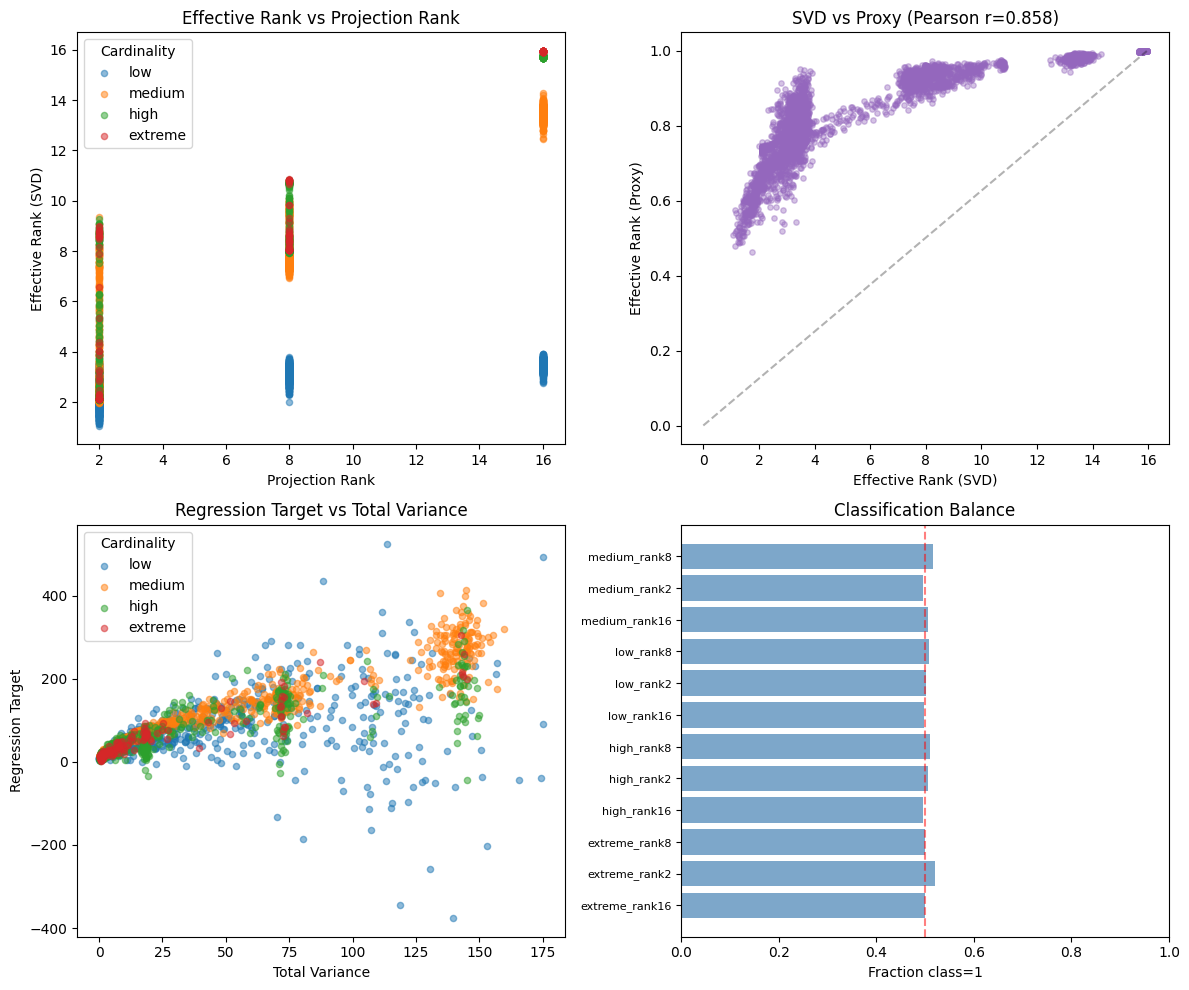

Saved: rank_collapse_analysis.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Extract data arrays
eranks = [r["metadata_erank_svd"] for r in all_rows]
proxies = [r["metadata_erank_proxy"] for r in all_rows]
proj_ranks = [r["metadata_projection_rank"] for r in all_rows]
cards = [r["metadata_cardinality_regime"] for r in all_rows]
total_vars = [sum(r["metadata_child_variance"]) for r in all_rows]
reg_targets = [json.loads(r["output"])["regression_target"] for r in all_rows]
cls_targets = [json.loads(r["output"])["classification_target"] for r in all_rows]

# 1. Effective rank vs projection rank by cardinality
ax = axes[0, 0]
card_colors = {"low": "tab:blue", "medium": "tab:orange", "high": "tab:green", "extreme": "tab:red"}
for card in ["low", "medium", "high", "extreme"]:
    mask = [c == card for c in cards]
    pr = [proj_ranks[i] for i, m in enumerate(mask) if m]
    er = [eranks[i] for i, m in enumerate(mask) if m]
    ax.scatter(pr, er, alpha=0.5, label=card, color=card_colors[card], s=20)
ax.set_xlabel("Projection Rank")
ax.set_ylabel("Effective Rank (SVD)")
ax.set_title("Effective Rank vs Projection Rank")
ax.legend(title="Cardinality")

# 2. SVD rank vs proxy
ax = axes[0, 1]
ax.scatter(eranks, proxies, alpha=0.4, s=15, color="tab:purple")
corr_val, _ = pearsonr(eranks, proxies)
ax.set_xlabel("Effective Rank (SVD)")
ax.set_ylabel("Effective Rank (Proxy)")
ax.set_title(f"SVD vs Proxy (Pearson r={corr_val:.3f})")
# Add diagonal reference
lims = [min(min(eranks), min(proxies)), max(max(eranks), max(proxies))]
ax.plot([0, max(eranks)], [0, max(proxies)], 'k--', alpha=0.3, label="trend")

# 3. Regression target vs total variance
ax = axes[1, 0]
for card in ["low", "medium", "high", "extreme"]:
    mask = [c == card for c in cards]
    tv = [total_vars[i] for i, m in enumerate(mask) if m]
    rt = [reg_targets[i] for i, m in enumerate(mask) if m]
    ax.scatter(tv, rt, alpha=0.5, label=card, color=card_colors[card], s=20)
ax.set_xlabel("Total Variance")
ax.set_ylabel("Regression Target")
ax.set_title("Regression Target vs Total Variance")
ax.legend(title="Cardinality")

# 4. Classification balance by condition
ax = axes[1, 1]
cond_names = sorted(set(r["metadata_condition"] for r in all_rows))
balances = []
for cn in cond_names:
    cr = [r for r in all_rows if r["metadata_condition"] == cn]
    labels = [json.loads(r["output"])["classification_target"] for r in cr]
    balances.append(sum(labels) / len(labels))
bars = ax.barh(range(len(cond_names)), balances, color="steelblue", alpha=0.7)
ax.set_yticks(range(len(cond_names)))
ax.set_yticklabels(cond_names, fontsize=8)
ax.set_xlabel("Fraction class=1")
ax.set_title("Classification Balance")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("rank_collapse_analysis.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: rank_collapse_analysis.png")